<a href="https://colab.research.google.com/github/Najaf-Ali12/Complete-NLP-Projects/blob/main/model/Finetuning_a_sentiment_analysis_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Loading required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import torch
from transformers import TrainingArguments, Trainer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import EarlyStoppingCallback
import wandb  # this is weight and bias library to visualize curves

In [2]:
# Loading Datasets
from datasets import load_dataset
dataset = load_dataset("syedkhalid0/Sentiment-Analysis")

README.md:   0%|          | 0.00/4.55k [00:00<?, ?B/s]

train_data.csv:   0%|          | 0.00/6.94M [00:00<?, ?B/s]

val_data.csv:   0%|          | 0.00/870k [00:00<?, ?B/s]

test_data.csv:   0%|          | 0.00/870k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/83989 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10499 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10499 [00:00<?, ? examples/s]

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 83989
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 10499
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 10499
    })
})

In [4]:
# Understanding Data
print("\nSample from training set:")
print(dataset['train'][0])
print(f"Text: {dataset['train'][100]['text']}")
print(f"Label: {dataset['train'][100]['label']}")


Sample from training set:
{'text': 'almost got in a giant car accident on the 101', 'label': 0}
Text: with terrific computer graphics , inventive action sequences and a droll sense of humor 
Label: 2


In [5]:
# Create mapping between labels and their names
id2label = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
label2id = {"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}

print("Label mappings:")
for label_id, label_name in id2label.items():
    print(f"{label_id}: {label_name}")

Label mappings:
0: NEGATIVE
1: NEUTRAL
2: POSITIVE


In [6]:
# Data Tokenization
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True,padding=False, max_length=512)

tokenized_dataset = dataset.map(tokenize_function, batched=True)

print("\nTokenized dataset structure:")
print(tokenized_dataset)
print(f"Tokenizer vocab size: {tokenizer.vocab_size}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/83989 [00:00<?, ? examples/s]

Map:   0%|          | 0/10499 [00:00<?, ? examples/s]

Map:   0%|          | 0/10499 [00:00<?, ? examples/s]


Tokenized dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 83989
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10499
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 10499
    })
})
Tokenizer vocab size: 30522


In [7]:
# Splitting data into training, validation and testing.
train_dataset=tokenized_dataset['train']
test_dataset=tokenized_dataset['test']
validation_dataset=tokenized_dataset["validation"]

# Will rename the label column to labels as the Trainer expects labels not label
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")
validation_dataset = validation_dataset.rename_column("label", "labels")

# Viewing the samples and length
print(f"Train: {len(train_dataset)} samples")
print(f"Validation: {len(validation_dataset)} samples")
print(f"Test: {len(test_dataset)} samples")

Train: 83989 samples
Validation: 10499 samples
Test: 10499 samples


In [8]:
# Load the pre-trained model for sequence classification task.
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,  # 3 classes: NEGATIVE, NEUTRAL, POSITIVE
    id2label=id2label,
    label2id=label2id
)


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
# Providing write access token to login in hugging face and push training progress directly to hugging face
from huggingface_hub import login
from google.colab import userdata

# using secret
write_token=userdata.get("hf_write_token")

# Paste your copied HF write token inside the quotes
login(write_token)

In [10]:
# Set up training arguments
training_args = TrainingArguments(
    output_dir="./sentiment_results",          # output directory
    num_train_epochs=3,                        # number of training epochs
    per_device_train_batch_size=16,            # batch size per device during training
    per_device_eval_batch_size=64,             # batch size for evaluation
    warmup_steps=500,                          # number of warmup steps
    weight_decay=0.01,                         # strength of weight decay
    logging_steps=100,                         # log every 100 steps
    eval_strategy="steps",               # evaluate every `eval_steps`
    eval_steps=500,                            # evaluation and saving steps
    save_steps=500,                            # save checkpoint every 500 steps
    load_best_model_at_end=True,               # load the best model when finished
    metric_for_best_model="f1",                # use F1 score to determine best model
    greater_is_better=True,                    # higher F1 is better
    push_to_hub=True,                         # don't push to Hugging Face Hub
    fp16=True,                                 # use mixed precision for faster training
    report_to="wandb",                         # send logs to weights and biases library for curve visualization
)

In [11]:
# Define matrix function for evaluation
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    f1 = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [12]:
# Initializing the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

In [13]:
# Initialize weights and biases for experiement tracking and visualizing the model performance during its training
wandb.init(project="transformer-fine-tuning", name="bert-mrpc-analysis")

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: contact-najafalialkhani (contact-najafalialkhani-quaid-e-awam-university-of-engin) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [14]:
# Train the model
print("\n" + "="*50)
print("Starting Training...")
print("="*50)

# Train the model
trainer.train()


Starting Training...


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
500,0.495046,0.459932,0.818078,0.825938,0.818078,0.820771
1000,0.422805,0.413963,0.835889,0.836859,0.835889,0.833826
1500,0.388778,0.418368,0.843033,0.840381,0.843033,0.840128
2000,0.404383,0.371926,0.857320,0.859505,0.857320,0.858244
2500,0.413596,0.363508,0.853986,0.854207,0.853986,0.852979
3000,0.368503,0.359646,0.864368,0.863892,0.864368,0.862971
3500,0.338037,0.350128,0.866463,0.866100,0.866463,0.864919
4000,0.344742,0.351441,0.867606,0.872117,0.867606,0.868445
4500,0.353690,0.319062,0.879608,0.880914,0.879608,0.879692
5000,0.338650,0.317045,0.881227,0.880667,0.881227,0.880928


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9500, training_loss=0.32360455161646795, metrics={'train_runtime': 1029.4657, 'train_samples_per_second': 244.755, 'train_steps_per_second': 15.299, 'total_flos': 3202433704515024.0, 'train_loss': 0.32360455161646795, 'epoch': 1.8095238095238095})

In [15]:
# Evaluate the model
print("\n" + "="*50)
print("Evaluating on Validation Set...")
print("="*50)

# Evaluate on validation set
val_results = trainer.evaluate()
print("\nValidation Results:")
for metric, value in val_results.items():
    print(f"{metric}: {value:.4f}")



Evaluating on Validation Set...


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.209729,0.327016,9500,0.889609,0.890465,0.889609,0.889998



Validation Results:
eval_loss: 0.3270
eval_accuracy: 0.8896
eval_precision: 0.8905
eval_recall: 0.8896
eval_f1: 0.8900


In [16]:
# Evaluation on test set
print("\n" + "="*50)
print("Evaluating on Test Set...")
print("="*50)

# Evaluate on test set
test_results = trainer.predict(test_dataset)
test_metrics = compute_metrics((test_results.predictions, test_results.label_ids))

print("\nTest Results:")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")


Evaluating on Test Set...



Test Results:
accuracy: 0.8902
precision: 0.8914
recall: 0.8902
f1: 0.8907


In [17]:
# Save the fine-tuned model locally
model_save_path = "./sentiment_model"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"\nModel saved to {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to ./sentiment_model


In [18]:
# Make predictions on text data
print("\n" + "="*50)
print("Testing on New Examples...")
print("="*50)

# Function to predict sentiment on new text
def predict_sentiment(texts, model, tokenizer):
    """
    Predict sentiment for a list of texts
    """
    # Tokenize the inputs
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    # Move inputs to the same device as model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}


Testing on New Examples...


In [19]:
# Function to predict sentiment on new text
def predict_sentiment(texts, model, tokenizer):
    """
    Predict sentiment for a list of texts
    """
    # Tokenize the inputs
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    # Move inputs to the same device as model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Get predictions
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.softmax(outputs.logits, dim=-1)
        predicted_classes = torch.argmax(predictions, dim=-1)
        confidence_scores = torch.max(predictions, dim=-1).values

    # Convert to numpy
    predicted_classes = predicted_classes.cpu().numpy()
    confidence_scores = confidence_scores.cpu().numpy()

    # Get label names
    predicted_labels = [id2label[cls] for cls in predicted_classes]

    return predicted_labels, confidence_scores, predictions.cpu().numpy()

In [20]:
# Test with some examples
test_texts = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "The food was terrible and the service was even worse.",
    "It was an okay experience, nothing special but not bad either.",
    "I can't believe how amazing this product is! Highly recommend!",
    "The battery life on this phone is average.",
    "Worst purchase I've ever made. Completely disappointed.",
]

print("\nPredictions on new texts:")
print("-" * 80)
labels, confidences, probs = predict_sentiment(test_texts, model, tokenizer)

for text, label, confidence in zip(test_texts, labels, confidences):
    sentiment_emoji = "😊" if label == "POSITIVE" else "😐" if label == "NEUTRAL" else "😞"
    print(f"Text: {text[:60]}...")
    print(f"Sentiment: {sentiment_emoji} {label} (confidence: {confidence:.2%})")
    print("-" * 80)


Predictions on new texts:
--------------------------------------------------------------------------------
Text: This movie was absolutely fantastic! I loved every minute of...
Sentiment: 😊 POSITIVE (confidence: 99.81%)
--------------------------------------------------------------------------------
Text: The food was terrible and the service was even worse....
Sentiment: 😞 NEGATIVE (confidence: 99.54%)
--------------------------------------------------------------------------------
Text: It was an okay experience, nothing special but not bad eithe...
Sentiment: 😊 POSITIVE (confidence: 72.67%)
--------------------------------------------------------------------------------
Text: I can't believe how amazing this product is! Highly recommen...
Sentiment: 😊 POSITIVE (confidence: 99.22%)
--------------------------------------------------------------------------------
Text: The battery life on this phone is average....
Sentiment: 😞 NEGATIVE (confidence: 67.01%)
----------------------------

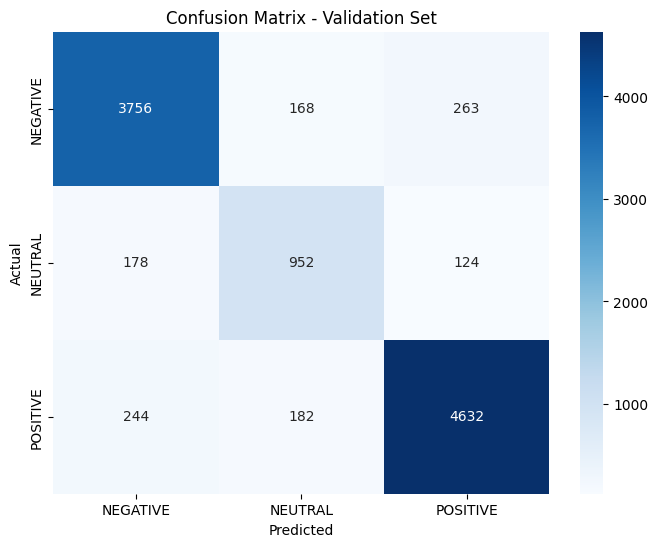

In [21]:
# ========== VISUALIZE RESULTS ==========
import matplotlib.pyplot as plt
import seaborn as sns

# Create a confusion matrix
from sklearn.metrics import confusion_matrix

# Get predictions on validation set
val_predictions = trainer.predict(validation_dataset)
predicted_labels = np.argmax(val_predictions.predictions, axis=1)
true_labels = val_predictions.label_ids

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'],
            yticklabels=['NEGATIVE', 'NEUTRAL', 'POSITIVE'])
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
# ========== SAVE METRICS TO FILE ==========
# Save all evaluation metrics to a text file
with open('evaluation_metrics.txt', 'w') as f:
    f.write("Sentiment Analysis Model Evaluation Results\n")
    f.write("="*50 + "\n\n")

    f.write("Validation Results:\n")
    for metric, value in val_results.items():
        if 'eval_' in metric:
            f.write(f"  {metric}: {value:.4f}\n")

    f.write("\nTest Results:\n")
    for metric, value in test_metrics.items():
        f.write(f"  {metric}: {value:.4f}\n")

    f.write(f"\nModel saved at: {model_save_path}\n")
    f.write(f"Number of training samples: {len(train_dataset)}\n")
    f.write(f"Number of validation samples: {len(validation_dataset)}\n")
    f.write(f"Number of test samples: {len(test_dataset)}\n")

print("\n" + "="*50)
print("✅ Project Complete!")
print("="*50)
print("Files saved:")
print(f"  - Model: {model_save_path}")
print(f"  - Metrics: evaluation_metrics.txt")
print(f"  - Checkpoints: ./sentiment_results/")


✅ Project Complete!
Files saved:
  - Model: ./sentiment_model
  - Metrics: evaluation_metrics.txt
  - Checkpoints: ./sentiment_results/


In [23]:
# Saving all the required models and requirements for app.py
# ========== SAVE THESE 3 ITEMS FROM YOUR NOTEBOOK ==========

# 1. Save the fine-tuned model and tokenizer
model_save_path = "./sentiment_model"
trainer.save_model(model_save_path)  # Saves model.bin and config.json
tokenizer.save_pretrained(model_save_path)  # Saves tokenizer files

# 2. Save the label mappings (important for predictions)
import json
id2label = {0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"}
label2id = {"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}

with open(f"{model_save_path}/label_mappings.json", "w") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f)

# 3. (Optional but recommended) Save the training metrics
import json
metrics = {
    "validation": val_results,
    "test": test_metrics,
    "model_info": {
        "base_model": "distilbert-base-uncased",
        "num_epochs": 3,
        "train_samples": len(train_dataset),
        "val_samples": len(validation_dataset),
        "test_samples": len(test_dataset)
    }
}

with open(f"{model_save_path}/model_info.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("✅ All necessary files saved successfully!")
print(f"📁 Model saved at: {model_save_path}/")
print("   Files included:")
print("   - model.bin")
print("   - config.json")
print("   - vocab.txt")
print("   - tokenizer_config.json")
print("   - label_mappings.json")
print("   - model_info.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ All necessary files saved successfully!
📁 Model saved at: ./sentiment_model/
   Files included:
   - model.bin
   - config.json
   - vocab.txt
   - tokenizer_config.json
   - label_mappings.json
   - model_info.json
